# Detecção de Fraudes em Transações de Cartão de Crédito

**Projeto de Parceria: EBAC x Semantix**
**Autor:** João Alfredo de Sousa Siqueira  
**Data:** Abril/2026  
**Dataset:** [Credit Card Transactions Fraud Detection — Kaggle](https://www.kaggle.com/datasets/kartik2112/fraud-detection) (Licença ODbL)  


## 1. Contexto do Problema

O mercado de pagamentos digitais brasileiro movimenta trilhões de reais por ano. Empresas como **PicPay**, **BoaVista** e **Travelex** lidam diariamente com o desafio de identificar transações fraudulentas em tempo real, sem bloquear transações legítimas e sem impactar a experiência do cliente.

Regras manuais como *"bloquear transações acima de R$ X em outro estado"* não escalam: fraudadores se adaptam rapidamente e qualquer regra fixa se torna obsoleta. Um modelo de machine learning que aprende padrões comportamentais diretamente dos dados é fundamentalmente superior, e é o que este projeto propõe.


## 2. Objetivo

Construir um modelo preditivo capaz de identificar transações fraudulentas com alta taxa de **Recall** — priorizando não deixar fraudes passarem, sem comprometer demasiadamente a Precisão, e com saldo financeiro líquido positivo para o negócio.

O sucesso do projeto não é medido apenas por métricas estatísticas, mas pelo impacto financeiro real: quanto dinheiro o modelo economiza após descontar o custo dos bloqueios indevidos.


## 3. Por que não usar Acurácia como métrica?

Com **99,42%** das transações sendo legítimas, um modelo que classifica *tudo* como legítimo atingiria 99,42% de Acurácia e seria completamente inútil, pois nunca detectaria uma fraude.

A métrica correta aqui é o **AUC-ROC** combinado com **F1-Score**, analisando o trade-off entre Precisão e Recall:

| Métrica | O que mede |
|---|---|
| **Recall** | De todas as fraudes reais, quantas o modelo encontrou? |
| **Precision** | De todos os alertas de fraude, quantos eram fraude de verdade? |
| **F1-Score** | Média harmônica entre Precisão e Recall |
| **AUC-ROC** | Capacidade geral de separar as classes |

> Um banco prefere bloquear algumas transações legítimas a deixar fraudes passarem. Logo, **Recall alto é prioridade** — mas legítimas bloqueadas em excesso geram custo operacional e insatisfação do cliente. O modelo ideal equilibra os dois lados e, idealmente, gera saldo financeiro positivo.


## 4. Imports e Configurações


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             RocCurveDisplay, f1_score, precision_score, recall_score,
                             precision_recall_curve, average_precision_score)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
import xgboost as xgb
import time
import warnings
warnings.filterwarnings('ignore')

# configurações para visualização
sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42
print('Imports OK')


Imports OK


## 5. Carregamento dos Dados

O dataset contém transações de cartão de crédito divididas em dois arquivos: treino (1.296.675 transações) e teste (555.719 transações). Cada linha representa uma transação com informações do titular, do estabelecimento, do valor e da data e um rótulo indicando se é fraude ou não.


In [4]:
# leitura dos arquivos CSV
train = pd.read_csv('fraudTrain.csv')
test  = pd.read_csv('fraudTest.csv')

print('Treino:', train.shape)
print('Teste :', test.shape)


Treino: (1296675, 23)
Teste : (555719, 23)


## 6. Análise Exploratória de Dados (EDA)

Antes de qualquer modelagem, precisamos entender o que os dados revelam sobre o comportamento das fraudes. Um bom EDA não é só estatística descritiva, é encontrar os padrões que vão guiar as decisões de feature engineering, balanceamento e escolha de métricas.


### 6.1 Visão Geral do Dataset

Primeiro verificamos a estrutura geral: tipos de dados, presença de valores nulos e distribuição estatística das variáveis numéricas. Qualquer problema aqui precisaria ser tratado antes de avançar.


In [5]:
# primeiras visualizações
print('INFORMAÇÕES GERAIS')
print(train.info())

print('\nVALORES NULOS')
print(train.isnull().sum())

print('\nESTATÍSTICAS DESCRITIVAS')
print(train.describe())


INFORMAÇÕES GERAIS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14 

### 6.2 Distribuição das Classes

O primeiro e mais importante diagnóstico: o quanto as classes estão desbalanceadas. Essa proporção vai determinar toda a estratégia de modelagem, desde a escolha das métricas até a abordagem de balanceamento.


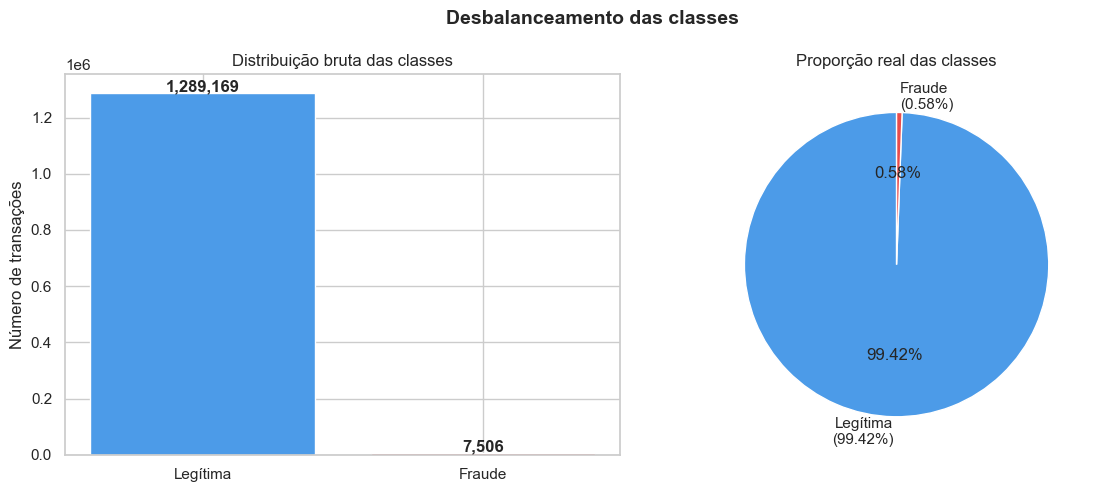

In [6]:
# visualização do desbalanceamento
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

contagem = train['is_fraud'].value_counts()

# gráfico de barras da distribuição bruta
axes[0].bar(['Legítima', 'Fraude'],
            [contagem[0], contagem[1]],
            color=['#4C9BE8', '#E84C4C'])
axes[0].set_title('Distribuição bruta das classes')
axes[0].set_ylabel('Número de transações')
for i, v in enumerate([contagem[0], contagem[1]]):
    axes[0].text(i, v + 5000, f'{v:,}', ha='center', fontweight='bold')

# gráfico de pizza da proporção real
axes[1].pie([contagem[0], contagem[1]],
            labels=[f'Legítima\n({contagem[0]/len(train)*100:.2f}%)',
                    f'Fraude\n({contagem[1]/len(train)*100:.2f}%)'],
            colors=['#4C9BE8', '#E84C4C'],
            autopct='%1.2f%%',
            startangle=90)
axes[1].set_title('Proporção real das classes')

plt.suptitle('Desbalanceamento das classes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('01_desbalanceamento.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.3 Valor das Transações Legítimas vs Fraudulentas

Analisamos a distribuição dos valores monetários separando legítimas de fraudulentas. Se houver diferença significativa, o valor da transação se torna um preditor natural, e isso terá implicações diretas no impacto financeiro do modelo.


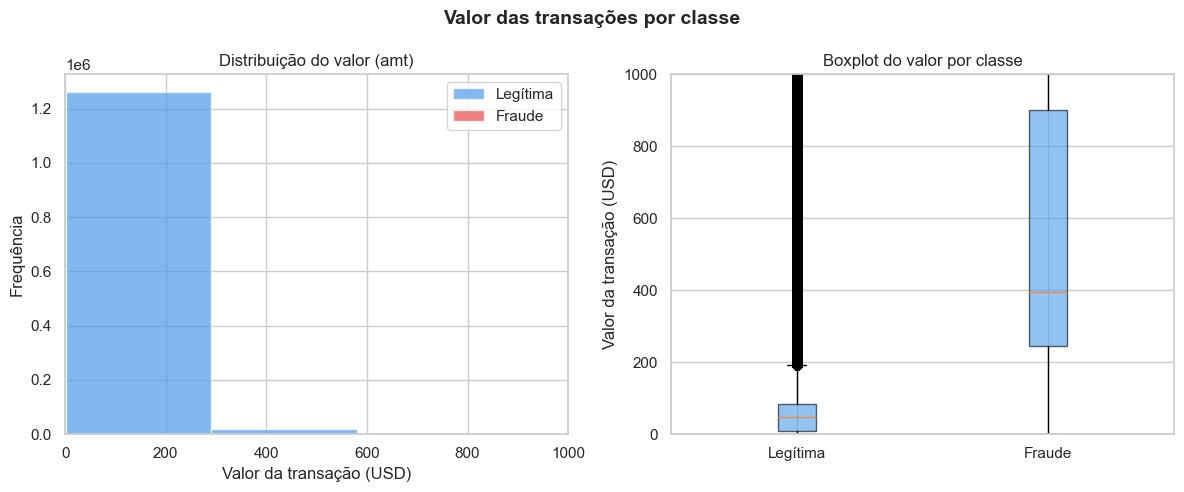

Média    — Legítima : USD 67.67
Média    — Fraude   : USD 531.32
Mediana  — Legítima : USD 47.28
Mediana  — Fraude   : USD 396.50


In [7]:
# análise do valor das transações por classe
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

legitimas    = train[train['is_fraud'] == 0]['amt']
fraudulentas = train[train['is_fraud'] == 1]['amt']

# histogramas lado a lado para comparar as distribuições
axes[0].hist(legitimas,    bins=100, color='#4C9BE8', alpha=0.7, label='Legítima')
axes[0].hist(fraudulentas, bins=100, color='#E84C4C', alpha=0.7, label='Fraude')
axes[0].set_xlim(0, 1000)
axes[0].set_title('Distribuição do valor (amt)')
axes[0].set_xlabel('Valor da transação (USD)')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# boxplot para comparar a dispersão e os outliers
axes[1].boxplot([legitimas, fraudulentas],
                labels=['Legítima', 'Fraude'],
                patch_artist=True,
                boxprops=dict(facecolor='#4C9BE8', alpha=0.6))
axes[1].set_title('Boxplot do valor por classe')
axes[1].set_ylabel('Valor da transação (USD)')
axes[1].set_ylim(0, 1000)

plt.suptitle('Valor das transações por classe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('02_valor_transacoes.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Média    — Legítima : USD {legitimas.mean():.2f}')
print(f'Média    — Fraude   : USD {fraudulentas.mean():.2f}')
print(f'Mediana  — Legítima : USD {legitimas.median():.2f}')
print(f'Mediana  — Fraude   : USD {fraudulentas.median():.2f}')


### 6.4 Categorias de Estabelecimento com Maior Taxa de Fraude

Nem todas as categorias de comércio têm o mesmo risco. Identificar quais concentram mais fraudes ajuda a entender o perfil do fraudador e confirma se a variável `category` vai agregar valor ao modelo.


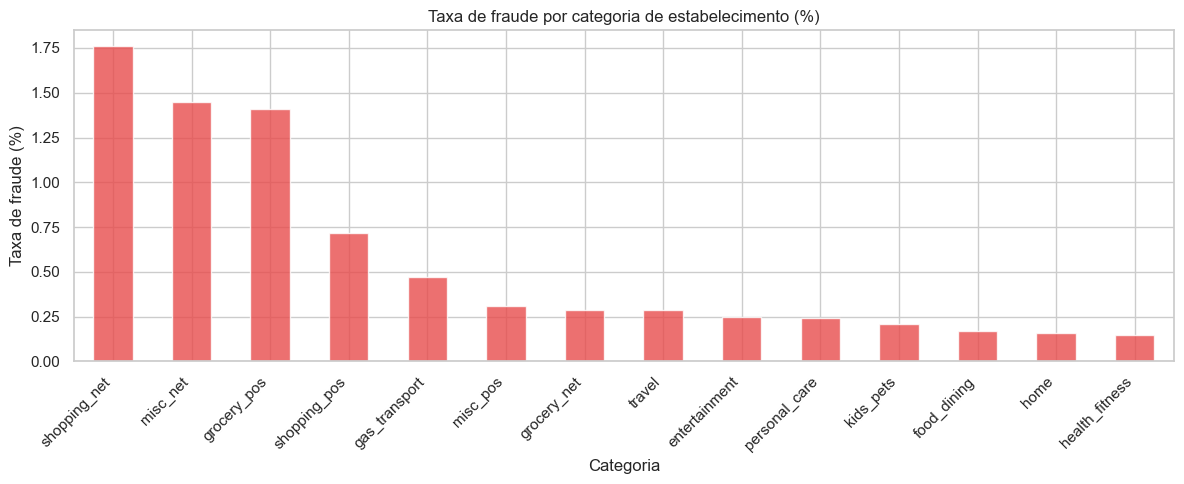

category
shopping_net      1.76
misc_net          1.45
grocery_pos       1.41
shopping_pos      0.72
gas_transport     0.47
misc_pos          0.31
grocery_net       0.29
travel            0.29
entertainment     0.25
personal_care     0.24
kids_pets         0.21
food_dining       0.17
home              0.16
health_fitness    0.15
Name: is_fraud, dtype: float64


In [8]:
# análise da taxa de fraude por categoria de estabelecimento
fraude_por_categoria = (train.groupby('category')['is_fraud']
                             .mean()
                             .sort_values(ascending=False)
                             .mul(100)
                             .round(2))

plt.figure(figsize=(12, 5))
fraude_por_categoria.plot(kind='bar', color='#E84C4C', alpha=0.8)
plt.title('Taxa de fraude por categoria de estabelecimento (%)')
plt.ylabel('Taxa de fraude (%)')
plt.xlabel('Categoria')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('03_fraude_por_categoria.png', dpi=150, bbox_inches='tight')
plt.show()

print(fraude_por_categoria)


### 6.5 Fraude por Gênero e Faixa de Valor

Cruzamos as fraudes com gênero do titular e faixa de valor da transação. Queremos entender se o comportamento fraudulento varia por perfil demográfico e se existe uma faixa de valor onde as fraudes se concentram.


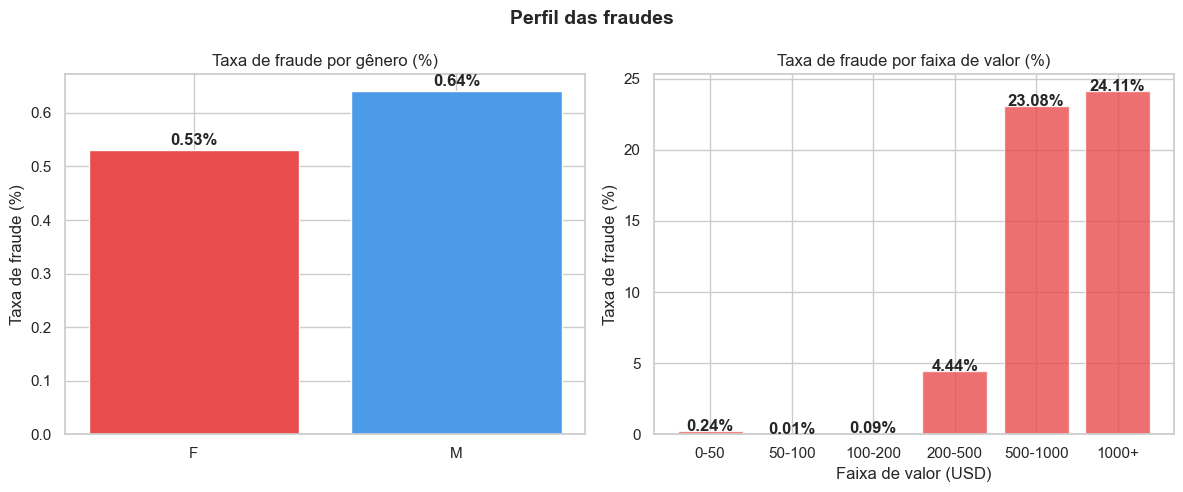

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# taxa de fraude por gênero
fraude_genero = (train.groupby('gender')['is_fraud']
                      .mean().mul(100).round(2))
axes[0].bar(fraude_genero.index, fraude_genero.values, color=['#E84C4C', '#4C9BE8'])
axes[0].set_title('Taxa de fraude por gênero (%)')
axes[0].set_ylabel('Taxa de fraude (%)')
for i, v in enumerate(fraude_genero.values):
    axes[0].text(i, v + 0.01, f'{v}%', ha='center', fontweight='bold')

bins        = [0, 50, 100, 200, 500, 1000, 99999]
labels_bins = ['0-50', '50-100', '100-200', '200-500', '500-1000', '1000+']
train['faixa_valor'] = pd.cut(train['amt'], bins=bins, labels=labels_bins)

# taxa de fraude por faixa de valor
fraude_faixa = (train.groupby('faixa_valor', observed=True)['is_fraud']
                     .mean().mul(100).round(2))
axes[1].bar(fraude_faixa.index, fraude_faixa.values, color='#E84C4C', alpha=0.8)
axes[1].set_title('Taxa de fraude por faixa de valor (%)')
axes[1].set_ylabel('Taxa de fraude (%)')
axes[1].set_xlabel('Faixa de valor (USD)')
for i, v in enumerate(fraude_faixa.values):
    axes[1].text(i, v + 0.02, f'{v}%', ha='center', fontweight='bold')

plt.suptitle('Perfil das fraudes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('04_perfil_fraudes.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.6 Insights do EDA

Os dados revelaram um perfil claro das transações fraudulentas:

- **Desbalanceamento severo:** apenas 0,58% das transações são fraudes (7.506 de 1.296.675). Modelos treinados sem tratamento tendem a ignorar completamente a classe minoritária, que é justamente o que queremos prever.

- **Valor é o preditor mais forte:** fraudes têm média de USD 531 contra USD 67 das legítimas. Acima de USD 500, mais de 23% das transações são fraudulentas — um sinal muito claro.

- **Categorias de risco:** `shopping_net` (1,75%), `misc_net` (1,44%) e `grocery_pos` (1,39%) concentram as maiores taxas. Categorias online (`_net`) são mais vulneráveis por não exigirem verificação física do cartão.

- **Gênero:** homens têm taxa ligeiramente maior (0,64% vs 0,53%), mas a diferença não é expressiva o suficiente para ser preditor isolado.

Esses quatro achados guiam diretamente as próximas decisões: quais colunas manter, quais features criar e qual estratégia de balanceamento adotar.


> **O EDA revelou o que precisamos saber.** O valor da transação é o sinal mais forte, as categorias online concentram as fraudes e o desbalanceamento de 171:1 exige tratamento especial. Com esse mapa em mãos, podemos preparar os dados de forma direcionada.


## 7. Pré-processamento

Com os insights do EDA em mãos, preparamos os dados para a modelagem. O objetivo aqui é duplo: remover o que não agrega e criar o que falta.


### 7.1 Remoção de Colunas Irrelevantes

Identificadores únicos como número do cartão, nome do titular e número da transação não têm poder preditivo, pelo contrário, podem causar overfitting se mantidos. Colunas de data e nascimento também são removidas aqui porque vamos extrair a informação útil delas na etapa de feature engineering.


In [10]:
# remoção das colunas irrelevantes ou redundantes
colunas_remover = [
    'Unnamed: 0',            # índice duplicado
    'trans_date_trans_time', # extrairemos features de tempo separadamente
    'cc_num',               # identificador único do cartão
    'first', 'last',        # nome do titular — não preditivo
    'street',               # endereço específico — muito granular
    'trans_num',            # ID único da transação
    'unix_time',            # redundante com trans_date_trans_time
    'dob',                  # data bruta — criaremos a feature 'idade'
    'faixa_valor'           # coluna auxiliar criada no EDA
]

train_clean = train.drop(columns=colunas_remover)
test_clean  = test.drop(columns=colunas_remover, errors='ignore')

print('Colunas restantes:', train_clean.columns.tolist())


Colunas restantes: ['merchant', 'category', 'amt', 'gender', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'merch_lat', 'merch_long', 'is_fraud']


### 7.2 Feature Engineering

Criamos quatro features novas a partir das colunas brutas. A lógica por trás de cada uma é baseada nos padrões observados no EDA:

| Feature | Origem | Motivação |
|---|---|---|
| `idade` | `dob` | Perfil demográfico do titular |
| `hora` | `trans_date_trans_time` | Fraudes tendem a ocorrer em horários específicos |
| `dia_semana` | `trans_date_trans_time` | Padrão comportamental semanal |
| `distancia` | `lat/long` vs `merch_lat/long` | Transações distantes do endereço são suspeitas |

A feature `distancia` é especialmente importante: um cartão usado a centenas de quilômetros do endereço cadastrado do titular é um sinal clássico de fraude.


In [11]:
# idade do titular
train_clean['idade'] = 2024 - pd.to_datetime(train['dob']).dt.year
test_clean['idade']  = 2024 - pd.to_datetime(test['dob']).dt.year

# hora da transação
train_clean['hora'] = pd.to_datetime(train['trans_date_trans_time']).dt.hour
test_clean['hora']  = pd.to_datetime(test['trans_date_trans_time']).dt.hour

# dia da semana
train_clean['dia_semana'] = pd.to_datetime(train['trans_date_trans_time']).dt.dayofweek
test_clean['dia_semana']  = pd.to_datetime(test['trans_date_trans_time']).dt.dayofweek

# distância geográfica entre cliente e estabelecimento
train_clean['distancia'] = np.sqrt(
    (train_clean['lat'] - train_clean['merch_lat'])**2 +
    (train_clean['long'] - train_clean['merch_long'])**2
)
test_clean['distancia'] = np.sqrt(
    (test_clean['lat'] - test_clean['merch_lat'])**2 +
    (test_clean['long'] - test_clean['merch_long'])**2
)

print('Features criadas com sucesso!')
print(train_clean[['idade', 'hora', 'dia_semana', 'distancia']].describe())


Features criadas com sucesso!
              idade          hora    dia_semana     distancia
count  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06
mean   5.074255e+01  1.280486e+01  3.070604e+00  7.656611e-01
std    1.737848e+01  6.817824e+00  2.198153e+00  2.847484e-01
min    1.900000e+01  0.000000e+00  0.000000e+00  2.386629e-04
25%    3.700000e+01  7.000000e+00  1.000000e+00  5.649579e-01
50%    4.900000e+01  1.400000e+01  3.000000e+00  7.983111e-01
75%    6.200000e+01  1.900000e+01  5.000000e+00  9.775357e-01
max    1.000000e+02  2.300000e+01  6.000000e+00  1.413364e+00


### 7.3 Encoding das Variáveis Categóricas

Algoritmos de machine learning trabalham com números. Convertemos as variáveis categóricas como `merchant`, `category`, `gender`, `city`, `state` e `job` em valores numéricos usando Label Encoding.


In [12]:
# transformação de variáveis categóricas em numéricas usando Label Encoding
categoricas = ['merchant', 'category', 'gender', 'city', 'state', 'job']

le = LabelEncoder()
for col in categoricas:
    train_clean[col] = le.fit_transform(train_clean[col].astype(str))
    test_clean[col]  = le.fit_transform(test_clean[col].astype(str))

print('Encoding concluído.')


Encoding concluído.


### 7.4 Separação de Features e Variável Alvo

Separamos o dataset em features (`X`) e variável alvo (`y`), e removemos as coordenadas geográficas brutas, a informação útil delas já foi capturada na feature `distancia`.


In [13]:
# definindo X e y para treino e teste
features_remover = ['is_fraud', 'lat', 'long', 'merch_lat', 'merch_long', 'zip']

X_train = train_clean.drop(columns=features_remover)
y_train = train_clean['is_fraud']

X_test  = test_clean.drop(columns=features_remover, errors='ignore')
y_test  = test_clean['is_fraud'] if 'is_fraud' in test_clean.columns else None

print('Shape X_train:', X_train.shape)
print('Shape X_test :', X_test.shape)
print('\nFeatures utilizadas:')
print(X_train.columns.tolist())
print('\nDistribuição y_train:')
print(y_train.value_counts())


Shape X_train: (1296675, 12)
Shape X_test : (555719, 12)

Features utilizadas:
['merchant', 'category', 'amt', 'gender', 'city', 'state', 'city_pop', 'job', 'idade', 'hora', 'dia_semana', 'distancia']

Distribuição y_train:
is_fraud
0    1289169
1       7506
Name: count, dtype: int64


## 8. Estratégia de Balanceamento

Com 99,42% de transações legítimas, treinar o modelo diretamente sem tratamento resultaria em um classificador que ignora fraudes completamente — ele simplesmente aprenderia a classificar tudo como legítimo e estaria certo 99% das vezes.

Avaliamos duas estratégias distintas para resolver esse problema. A escolha entre elas vai impactar diretamente a qualidade do modelo final.


### 8.1 Estratégia 1: SMOTE + Undersampling

A primeira abordagem trabalha com reamostragem dos dados antes do treino:

1. **RandomUnderSampler:** reduz a classe majoritária para 10 vezes o tamanho da minoritária, diminuindo o volume de dados antes do SMOTE.
2. **SMOTE (Synthetic Minority Oversampling Technique):** gera amostras sintéticas da classe minoritária interpolando entre exemplos reais, até atingir proporção 1:2.

O SMOTE resolve o desbalanceamento, mas tem uma limitação: ele cria dados artificiais. Isso pode gerar fronteiras de decisão mais agressivas, aumentando os falsos positivos — clientes legítimos bloqueados por engano.


In [14]:
# análise da distribuição antes do balanceamento
print('Distribuição antes do balanceamento:')
print(Counter(y_train))
print(f'Razão: 1 fraude para cada {Counter(y_train)[0] // Counter(y_train)[1]} legítimas')

# configuração do pipeline SMOTE
under = RandomUnderSampler(sampling_strategy=0.1, random_state=RANDOM_STATE)
over  = SMOTE(sampling_strategy=0.5, random_state=RANDOM_STATE)

# balanceamento combinado
pipeline_bal = Pipeline([('under', under), ('over', over)])
X_bal, y_bal = pipeline_bal.fit_resample(X_train, y_train)

total_bal = len(y_bal)
print('\nDistribuição após SMOTE + Undersampling:')
print(Counter(y_bal))
print(f"Legítimas : {Counter(y_bal)[0]:,} ({Counter(y_bal)[0]/total_bal*100:.1f}%)")
print(f"Fraudes   : {Counter(y_bal)[1]:,} ({Counter(y_bal)[1]/total_bal*100:.1f}%)")


Distribuição antes do balanceamento:
Counter({0: 1289169, 1: 7506})
Razão: 1 fraude para cada 171 legítimas

Distribuição após SMOTE + Undersampling:
Counter({0: 75060, 1: 37530})
Legítimas : 75,060 (66.7%)
Fraudes   : 37,530 (33.3%)


### 8.2 Estratégia 2: scale_pos_weight

A segunda abordagem não toca nos dados — ela instrui o próprio algoritmo a tratar as classes de forma assimétrica. O parâmetro `scale_pos_weight` do XGBoost define quantas vezes mais o modelo deve penalizar um erro na classe minoritária.

Ao usar a razão real de desbalanceamento (171:1), o modelo aprende a detectar fraudes nos dados originais, sem síntese artificial. Isso tende a produzir fronteiras de decisão mais precisas e menos falsos positivos.


In [15]:
# calculando a razão de desbalanceamento
ratio = Counter(y_train)[0] / Counter(y_train)[1]
print(f'Razão de desbalanceamento: {ratio:.1f}')
print(f'scale_pos_weight que será usado: {ratio:.1f}')
print('\nO modelo treinará diretamente nos dados originais sem resampling.')


Razão de desbalanceamento: 171.8
scale_pos_weight que será usado: 171.8

O modelo treinará diretamente nos dados originais sem resampling.


### 8.3 Comparação Visual das Estratégias

Para deixar claro o que o SMOTE faz com os dados de treino antes de comparar os resultados dos modelos:


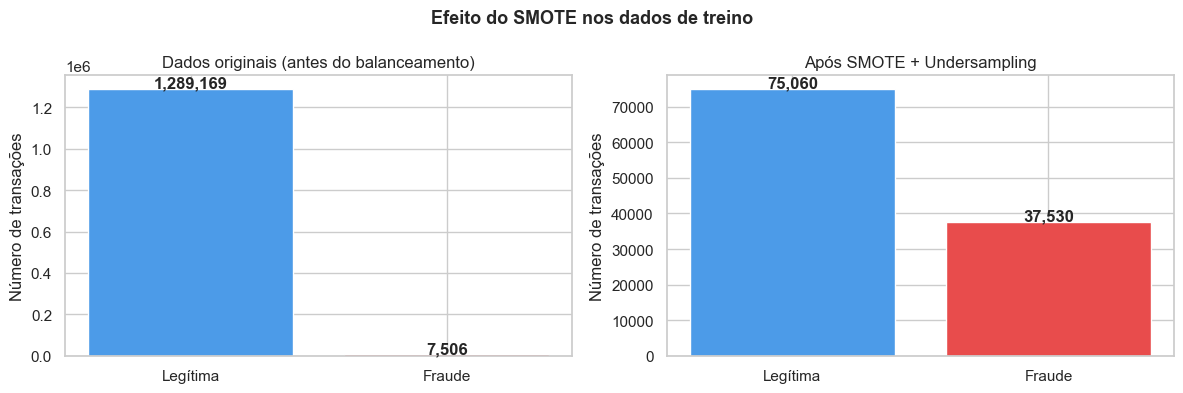

In [16]:
# visualização do impacto do SMOTE para referência
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Legítima', 'Fraude'], [Counter(y_train)[0], Counter(y_train)[1]], color=['#4C9BE8', '#E84C4C'])
axes[0].set_title('Dados originais (antes do balanceamento)')
axes[0].set_ylabel('Número de transações')
for i, v in enumerate([Counter(y_train)[0], Counter(y_train)[1]]):
    axes[0].text(i, v + 5000, f'{v:,}', ha='center', fontweight='bold')

axes[1].bar(['Legítima', 'Fraude'], [Counter(y_bal)[0], Counter(y_bal)[1]], color=['#4C9BE8', '#E84C4C'])
axes[1].set_title('Após SMOTE + Undersampling')
axes[1].set_ylabel('Número de transações')
for i, v in enumerate([Counter(y_bal)[0], Counter(y_bal)[1]]):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

plt.suptitle('Efeito do SMOTE nos dados de treino', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('05_balanceamento.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Modelagem

Treinamos três modelos para ter uma comparação completa. A Árvore de Decisão serve como baseline — um modelo mais simples que estabelece um piso de performance. Os dois XGBoost testam as estratégias de balanceamento avaliadas na seção anterior.


### 9.1 Árvore de Decisão (baseline)

Modelo mais simples e interpretável. Treinado nos dados balanceados com SMOTE, serve como referência para avaliar se modelos mais complexos realmente agregam valor.


In [17]:
# configuração e treino da Árvore de Decisão nos dados balanceados
print('Treinando Árvore de Decisão...')
inicio = time.time()

arvore = DecisionTreeClassifier(
    max_depth=10,
    min_samples_leaf=20,
    random_state=RANDOM_STATE
)
arvore.fit(X_bal, y_bal)
print(f'Tempo de treino: {time.time() - inicio:.1f}s')

y_pred_arvore = arvore.predict(X_test)
y_prob_arvore = arvore.predict_proba(X_test)[:, 1]

print('\nÁRVORE DE DECISÃO')
print(classification_report(y_test, y_pred_arvore, target_names=['Legítima', 'Fraude']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_arvore):.4f}')


Treinando Árvore de Decisão...
Tempo de treino: 1.0s

ÁRVORE DE DECISÃO
              precision    recall  f1-score   support

    Legítima       1.00      0.98      0.99    553574
      Fraude       0.16      0.93      0.27      2145

    accuracy                           0.98    555719
   macro avg       0.58      0.96      0.63    555719
weighted avg       1.00      0.98      0.99    555719

AUC-ROC: 0.9842


### 9.2 XGBoost com SMOTE

Modelo de gradient boosting treinado nos dados sintéticos gerados pelo SMOTE. O XGBoost é conhecido por seu desempenho superior em dados tabulares e é amplamente usado no setor financeiro para detecção de fraudes.


In [18]:
# configuração e treino do XGBoost nos dados balanceados com SMOTE
print('Treinando XGBoost (SMOTE)...')
inicio = time.time()

xgb_smote = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    verbosity=0
)
xgb_smote.fit(X_bal, y_bal)
print(f'Tempo de treino: {time.time() - inicio:.1f}s')

y_pred_smote = xgb_smote.predict(X_test)
y_prob_smote = xgb_smote.predict_proba(X_test)[:, 1]

print('\nXGBOOST — SMOTE')
print(classification_report(y_test, y_pred_smote, target_names=['Legítima', 'Fraude']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_smote):.4f}')


Treinando XGBoost (SMOTE)...
Tempo de treino: 2.0s

XGBOOST — SMOTE
              precision    recall  f1-score   support

    Legítima       1.00      0.99      0.99    553574
      Fraude       0.19      0.90      0.32      2145

    accuracy                           0.98    555719
   macro avg       0.60      0.94      0.65    555719
weighted avg       1.00      0.98      0.99    555719

AUC-ROC: 0.9892


### 9.3 XGBoost com scale_pos_weight

O mesmo algoritmo XGBoost, mas treinado diretamente nos dados originais com o parâmetro `scale_pos_weight` ajustado para compensar o desbalanceamento. Sem dados sintéticos, o modelo aprende padrões exclusivamente dos exemplos reais.


In [19]:
# configuração e treino do XGBoost nos dados originais com scale_pos_weight
print('Treinando XGBoost (scale_pos_weight)...')
inicio = time.time()

xgb_spw = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    verbosity=0
)
xgb_spw.fit(X_train, y_train)
print(f'Tempo de treino: {time.time() - inicio:.1f}s')

y_pred_spw = xgb_spw.predict(X_test)
y_prob_spw = xgb_spw.predict_proba(X_test)[:, 1]

print('\nXGBOOST — scale_pos_weight')
print(classification_report(y_test, y_pred_spw, target_names=['Legítima', 'Fraude']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_spw):.4f}')


Treinando XGBoost (scale_pos_weight)...
Tempo de treino: 14.8s

XGBOOST — scale_pos_weight
              precision    recall  f1-score   support

    Legítima       1.00      0.99      1.00    553574
      Fraude       0.28      0.95      0.43      2145

    accuracy                           0.99    555719
   macro avg       0.64      0.97      0.71    555719
weighted avg       1.00      0.99      0.99    555719

AUC-ROC: 0.9972


## 10. Comparação dos Modelos

Com os três modelos treinados, avaliamos o desempenho de cada um no conjunto de teste — dados que nenhum deles viu durante o treino. Essa é a avaliação que realmente importa.


### 10.1 Tabela Comparativa

Uma visão consolidada das principais métricas para os três modelos:


In [20]:
# tabela comparativa calculada dinamicamente
resultados = pd.DataFrame({
    'Modelo'             : ['Árvore de Decisão', 'XGBoost SMOTE', 'XGBoost scale_pos_weight'],
    'Precision (Fraude)' : [round(precision_score(y_test, y_pred_arvore), 2),
                            round(precision_score(y_test, y_pred_smote), 2),
                            round(precision_score(y_test, y_pred_spw), 2)],
    'Recall (Fraude)'    : [round(recall_score(y_test, y_pred_arvore), 2),
                            round(recall_score(y_test, y_pred_smote), 2),
                            round(recall_score(y_test, y_pred_spw), 2)],
    'F1 (Fraude)'        : [round(f1_score(y_test, y_pred_arvore), 2),
                            round(f1_score(y_test, y_pred_smote), 2),
                            round(f1_score(y_test, y_pred_spw), 2)],
    'AUC-ROC'            : [round(roc_auc_score(y_test, y_prob_arvore), 4),
                            round(roc_auc_score(y_test, y_prob_smote), 4),
                            round(roc_auc_score(y_test, y_prob_spw), 4)],
})
print(resultados.to_string(index=False))


                  Modelo  Precision (Fraude)  Recall (Fraude)  F1 (Fraude)  AUC-ROC
       Árvore de Decisão                0.16             0.93         0.27   0.9842
           XGBoost SMOTE                0.19             0.90         0.32   0.9892
XGBoost scale_pos_weight                0.28             0.95         0.43   0.9972


### 10.2 Gráfico Comparativo e Curva ROC

O gráfico de barras facilita a comparação visual das métricas. A curva ROC mostra a capacidade de cada modelo de separar as classes em diferentes pontos de corte — quanto mais próxima do canto superior esquerdo, melhor.


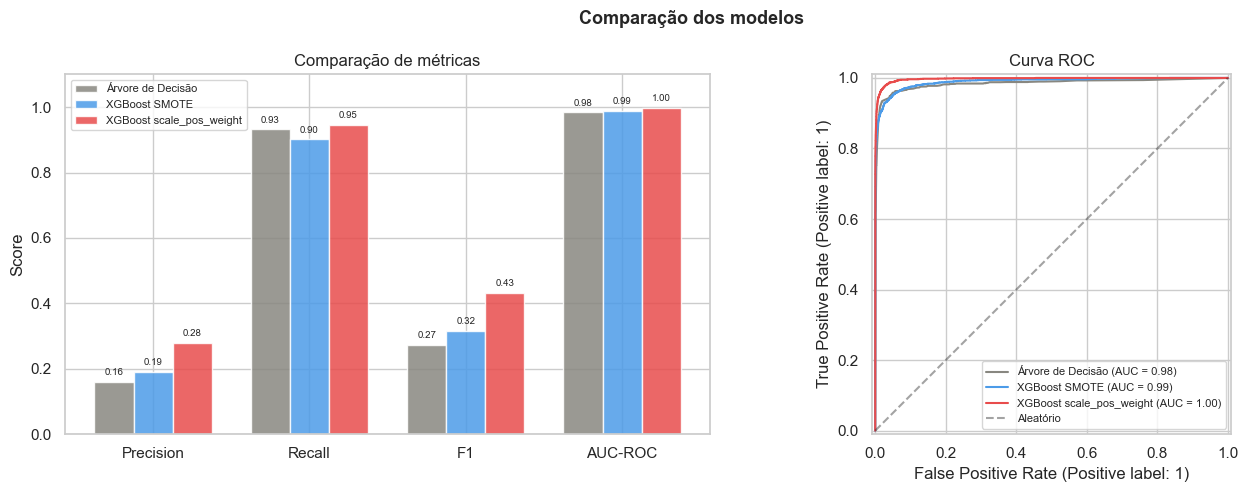

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels_metricas = ['Precision', 'Recall', 'F1', 'AUC-ROC']
vals_arvore = [precision_score(y_test, y_pred_arvore), recall_score(y_test, y_pred_arvore),
               f1_score(y_test, y_pred_arvore), roc_auc_score(y_test, y_prob_arvore)]
vals_smote  = [precision_score(y_test, y_pred_smote), recall_score(y_test, y_pred_smote),
               f1_score(y_test, y_pred_smote), roc_auc_score(y_test, y_prob_smote)]
vals_spw    = [precision_score(y_test, y_pred_spw), recall_score(y_test, y_pred_spw),
               f1_score(y_test, y_pred_spw), roc_auc_score(y_test, y_prob_spw)]

x     = np.arange(len(labels_metricas))
width = 0.25

axes[0].bar(x - width, vals_arvore, width, label='Árvore de Decisão',        color='#888780', alpha=0.85)
axes[0].bar(x,         vals_smote,  width, label='XGBoost SMOTE',             color='#4C9BE8', alpha=0.85)
axes[0].bar(x + width, vals_spw,    width, label='XGBoost scale_pos_weight',  color='#E84C4C', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels_metricas)
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Comparação de métricas')
axes[0].set_ylabel('Score')
axes[0].legend(fontsize=8)
for i, (a, b, c) in enumerate(zip(vals_arvore, vals_smote, vals_spw)):
    axes[0].text(i - width, a + 0.02, f'{a:.2f}', ha='center', fontsize=7)
    axes[0].text(i,         b + 0.02, f'{b:.2f}', ha='center', fontsize=7)
    axes[0].text(i + width, c + 0.02, f'{c:.2f}', ha='center', fontsize=7)

# curva ROC
RocCurveDisplay.from_predictions(y_test, y_prob_arvore, name='Árvore de Decisão',       ax=axes[1], color='#888780')
RocCurveDisplay.from_predictions(y_test, y_prob_smote,  name='XGBoost SMOTE',            ax=axes[1], color='#4C9BE8')
RocCurveDisplay.from_predictions(y_test, y_prob_spw,    name='XGBoost scale_pos_weight', ax=axes[1], color='#E84C4C')
axes[1].plot([0,1],[0,1], 'k--', alpha=0.4, label='Aleatório')
axes[1].set_title('Curva ROC')
axes[1].legend(fontsize=8)

plt.suptitle('Comparação dos modelos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('06_comparacao_modelos.png', dpi=150, bbox_inches='tight')
plt.show()


### 10.3 Matrizes de Confusão

As matrizes de confusão revelam onde cada modelo erra. Os números que mais importam para o negócio são os falsos negativos (fraudes que passaram) e os falsos positivos (legítimas bloqueadas por engano).


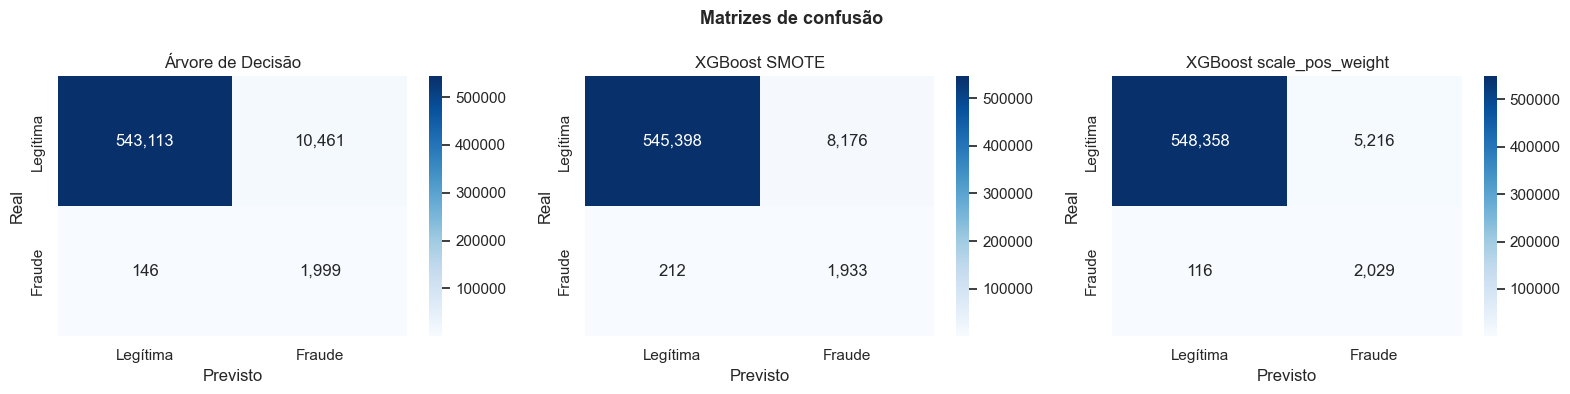

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, y_pred, titulo in zip(axes,
    [y_pred_arvore, y_pred_smote, y_pred_spw],
    ['Árvore de Decisão', 'XGBoost SMOTE', 'XGBoost scale_pos_weight']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=ax,
                xticklabels=['Legítima', 'Fraude'],
                yticklabels=['Legítima', 'Fraude'])
    ax.set_title(titulo)
    ax.set_ylabel('Real')
    ax.set_xlabel('Previsto')

plt.suptitle('Matrizes de confusão', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('07_matrizes_confusao.png', dpi=150, bbox_inches='tight')
plt.show()


### 10.4 Importância das Features — XGBoost scale_pos_weight

Entender quais variáveis o modelo considera mais relevantes confirma se as decisões de feature engineering foram acertadas — e fornece insights de negócio independentes do modelo em si.


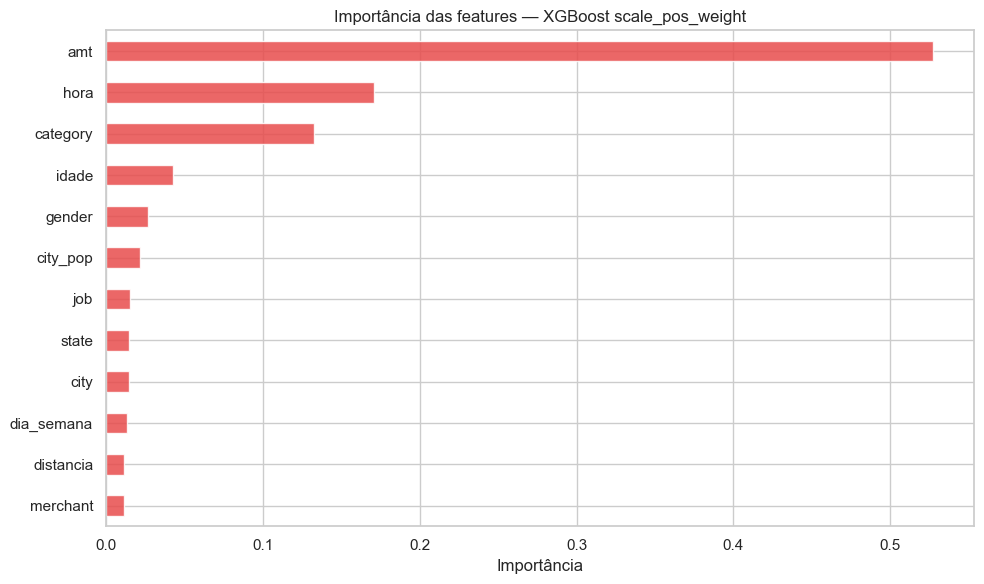

In [23]:
# análise da importância das features no modelo principal
feat_imp = pd.Series(xgb_spw.feature_importances_, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='#E84C4C', alpha=0.85)
plt.title('Importância das features — XGBoost scale_pos_weight')
plt.xlabel('Importância')
plt.tight_layout()
plt.savefig('08_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


### 10.5 Análise de Threshold e Curva Precision-Recall

Por padrão, modelos de classificação usam threshold de 0.5 para decidir entre as classes. Mas esse valor raramente é o ideal. Aqui buscamos o threshold que maximiza o F1-Score — o equilíbrio entre Precision e Recall — para o modelo principal.

A curva Precision-Recall é especialmente útil em dados desbalanceados porque, ao contrário da curva ROC, ela é sensível à proporção real das classes.


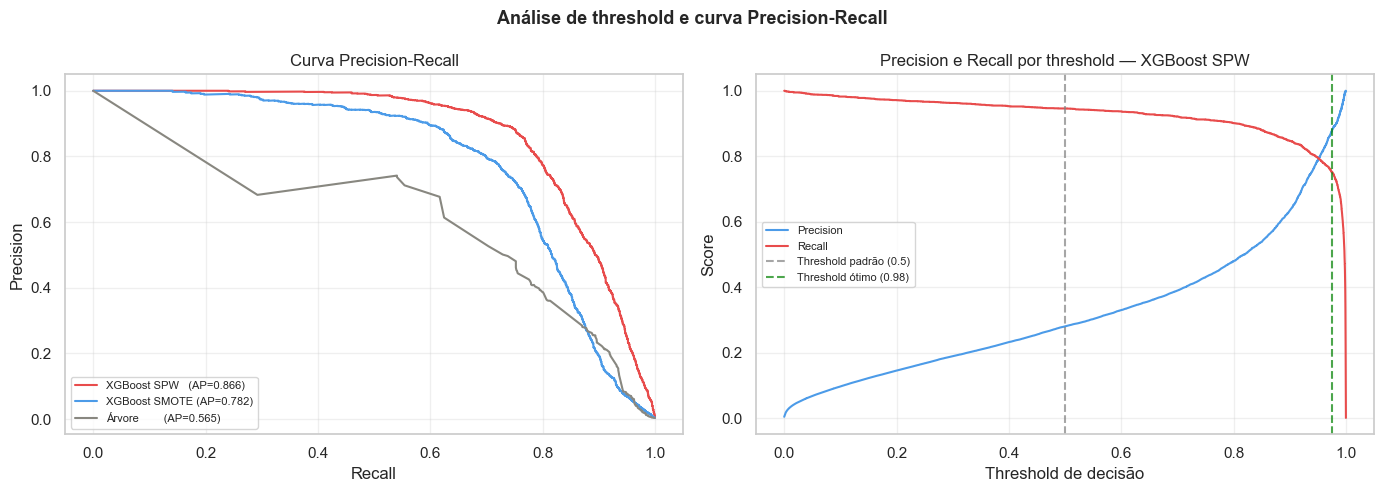

Threshold padrão (0.5)  — Precision: 0.280 | Recall: 0.946
Threshold ótimo (0.98) — Precision: 0.882 | Recall: 0.752 | F1: 0.812


In [24]:
# calculando as curvas para os três modelos
prec_spw,   rec_spw,   thresh_spw   = precision_recall_curve(y_test, y_prob_spw)
prec_smote, rec_smote, thresh_smote = precision_recall_curve(y_test, y_prob_smote)
prec_arv,   rec_arv,   thresh_arv   = precision_recall_curve(y_test, y_prob_arvore)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# curva precision-recall
axes[0].plot(rec_spw,   prec_spw,   color='#E84C4C', label=f'XGBoost SPW   (AP={average_precision_score(y_test, y_prob_spw):.3f})')
axes[0].plot(rec_smote, prec_smote, color='#4C9BE8', label=f'XGBoost SMOTE (AP={average_precision_score(y_test, y_prob_smote):.3f})')
axes[0].plot(rec_arv,   prec_arv,   color='#888780', label=f'Árvore        (AP={average_precision_score(y_test, y_prob_arvore):.3f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Curva Precision-Recall')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# análise do threshold — modelo principal (scale_pos_weight)
f1_por_threshold = 2 * (prec_spw[:-1] * rec_spw[:-1]) / (prec_spw[:-1] + rec_spw[:-1] + 1e-8)
idx_melhor       = f1_por_threshold.argmax()
thresh_otimo     = thresh_spw[idx_melhor]

axes[1].plot(thresh_spw, prec_spw[:-1], color='#4C9BE8', label='Precision')
axes[1].plot(thresh_spw, rec_spw[:-1],  color='#E84C4C', label='Recall')
axes[1].axvline(x=0.5,        color='gray',  linestyle='--', alpha=0.7, label='Threshold padrão (0.5)')
axes[1].axvline(x=thresh_otimo, color='green', linestyle='--', alpha=0.7,
                label=f'Threshold ótimo ({thresh_otimo:.2f})')
axes[1].set_xlabel('Threshold de decisão')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision e Recall por threshold — XGBoost SPW')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Análise de threshold e curva Precision-Recall', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('09_threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Threshold padrão (0.5)  — Precision: {prec_spw[np.searchsorted(thresh_spw, 0.5)]:.3f} | Recall: {rec_spw[np.searchsorted(thresh_spw, 0.5)]:.3f}')
print(f'Threshold ótimo ({thresh_otimo:.2f}) — Precision: {prec_spw[idx_melhor]:.3f} | Recall: {rec_spw[idx_melhor]:.3f} | F1: {f1_por_threshold[idx_melhor]:.3f}')


### 10.6 Impacto Financeiro — Comparação entre Estratégias

Métricas estatísticas são importantes, mas a pergunta final é sempre: quanto dinheiro o modelo economiza? Aqui traduzimos os resultados em valor financeiro concreto, comparando todas as combinações de estratégia e threshold.

O saldo líquido é calculado como:

> **Saldo = Fraudes evitadas (USD) - Legítimas bloqueadas indevidamente (USD)**

Um saldo positivo significa que o modelo cria valor real para o negócio. Um saldo negativo significa que o custo operacional dos bloqueios indevidos supera o valor das fraudes interceptadas.


Métrica                       SMOTE 0.5   SMOTE 0.97    SPW 0.5   SPW 0.98
Alertas gerados                  10,109        1,960      7,245      1,827
Falsos positivos                  8,176          423      5,216        215
---------------------------------------------------------------------------
Fraudes evitadas (USD)        1,122,095      996,639  1,122,442    998,614
Legítimas bloqueadas (USD)    2,050,334      335,484  1,824,721    183,964
Saldo líquido (USD)            -928,239      661,155   -702,278    814,651


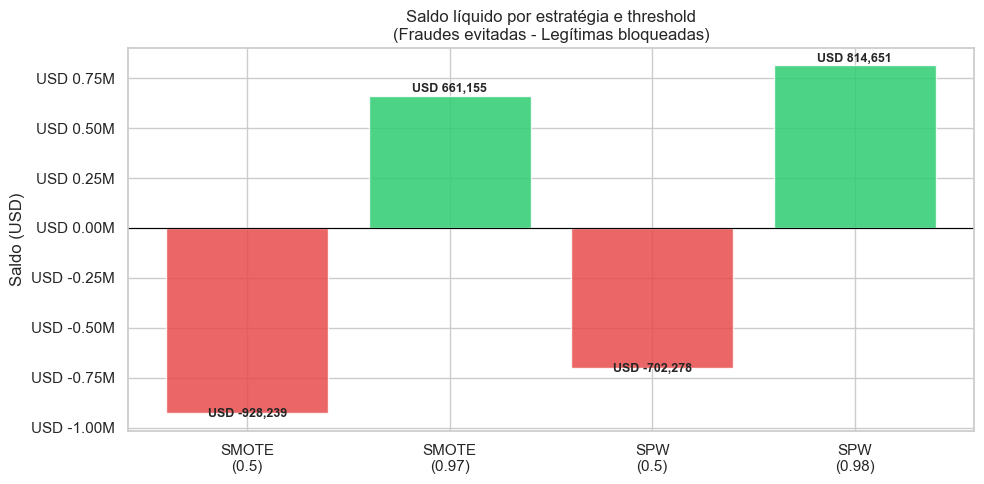

In [25]:
# função de cálculo de impacto financeiro
def calcular_impacto(y_real, y_pred, valores):
    tp = ((y_real == 1) & (y_pred == 1))
    fn = ((y_real == 1) & (y_pred == 0))
    fp = ((y_real == 0) & (y_pred == 1))
    evitadas   = valores[tp].sum()
    perdidas   = valores[fn].sum()
    bloqueadas = valores[fp].sum()
    return {
        'n_alertas'  : int(y_pred.sum()),
        'n_tp'       : int(tp.sum()),
        'n_fp'       : int(fp.sum()),
        'evitadas'   : evitadas,
        'perdidas'   : perdidas,
        'bloqueadas' : bloqueadas,
        'saldo'      : evitadas - bloqueadas,
    }

valores_test = X_test['amt'].values
y_real       = y_test.values

# threshold ótimo para cada modelo
f1_smote        = 2 * (prec_smote[:-1] * rec_smote[:-1]) / (prec_smote[:-1] + rec_smote[:-1] + 1e-8)
thresh_smote_ot = thresh_smote[f1_smote.argmax()]
thresh_spw_ot   = thresh_otimo  # calculado acima

y_pred_smote_ot = (y_prob_smote >= thresh_smote_ot).astype(int)
y_pred_spw_ot   = (y_prob_spw   >= thresh_spw_ot).astype(int)

res_smote_pad = calcular_impacto(y_real, y_pred_smote,    valores_test)
res_smote_ot  = calcular_impacto(y_real, y_pred_smote_ot, valores_test)
res_spw_pad   = calcular_impacto(y_real, y_pred_spw,      valores_test)
res_spw_ot    = calcular_impacto(y_real, y_pred_spw_ot,   valores_test)

# tabela comparativa
print('=' * 75)
print(f'{"Métrica":28} {"SMOTE 0.5":>10} {f"SMOTE {thresh_smote_ot:.2f}":>12} {"SPW 0.5":>10} {f"SPW {thresh_spw_ot:.2f}":>10}')
print('=' * 75)
for chave, label in [
    ('n_alertas',  'Alertas gerados'),
    ('n_fp',       'Falsos positivos'),
]:
    vs = [res_smote_pad[chave], res_smote_ot[chave], res_spw_pad[chave], res_spw_ot[chave]]
    print(f'{label:28} {vs[0]:>10,} {vs[1]:>12,} {vs[2]:>10,} {vs[3]:>10,}')
print('-' * 75)
for chave, label in [
    ('evitadas',   'Fraudes evitadas (USD)'),
    ('bloqueadas', 'Legítimas bloqueadas (USD)'),
    ('saldo',      'Saldo líquido (USD)'),
]:
    vs = [res_smote_pad[chave], res_smote_ot[chave], res_spw_pad[chave], res_spw_ot[chave]]
    print(f'{label:28} {vs[0]:>10,.0f} {vs[1]:>12,.0f} {vs[2]:>10,.0f} {vs[3]:>10,.0f}')
print('=' * 75)

# gráfico do saldo líquido por cenário
cenarios = [f'SMOTE\n(0.5)', f'SMOTE\n({thresh_smote_ot:.2f})', f'SPW\n(0.5)', f'SPW\n({thresh_spw_ot:.2f})']
saldos   = [res_smote_pad['saldo'], res_smote_ot['saldo'], res_spw_pad['saldo'], res_spw_ot['saldo']]
cores    = ['#E84C4C' if s < 0 else '#2ECC71' for s in saldos]

plt.figure(figsize=(10, 5))
bars = plt.bar(cenarios, saldos, color=cores, alpha=0.85)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Saldo líquido por estratégia e threshold\n(Fraudes evitadas - Legítimas bloqueadas)')
plt.ylabel('Saldo (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'USD {v/1e6:.2f}M'))
for bar, val in zip(bars, saldos):
    plt.text(bar.get_x() + bar.get_width()/2,
             val + (max(abs(s) for s in saldos) * 0.02 * (1 if val >= 0 else -1)),
             f'USD {val:,.0f}', ha='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.savefig('10_saldo_por_cenario.png', dpi=150, bbox_inches='tight')
plt.show()


### 10.7 Síntese da Comparação

Os resultados confirmam a hipótese levantada na seção de balanceamento: dados sintéticos do SMOTE criam fronteiras de decisão agressivas. O XGBoost com `scale_pos_weight` aprende padrões mais precisos porque treina exclusivamente em exemplos reais.

O gráfico de saldo líquido conta a história mais importante: com o threshold padrão de 0.5, nenhuma estratégia é financeiramente viável. A otimização do threshold transforma ambos os modelos em lucrativos — mas o `scale_pos_weight` chega a +USD 814k contra +USD 658k do SMOTE.

Antes de declarar o `scale_pos_weight` como modelo final, precisamos garantir que esse resultado não é fruto de um split de dados favorável. É o que o cross-validation vai verificar.


## 11. Cross-Validation — Módulo 37

Um bom resultado no conjunto de teste pode ser sorte. O cross-validation com **Stratified K-Fold (5 folds)** garante que o modelo performa de forma consistente em diferentes subconjuntos dos dados — e não apenas no split específico que temos.

O Stratified K-Fold é usado em vez do K-Fold simples para garantir que a proporção de fraudes seja preservada em cada fold, respeitando o desbalanceamento original.


CROSS-VALIDATION — XGBoost scale_pos_weight (5 folds)
f1          : 0.5603 (+/- 0.0066)
roc_auc     : 0.9981 (+/- 0.0005)
precision   : 0.3956 (+/- 0.0064)
recall      : 0.9602 (+/- 0.0029)


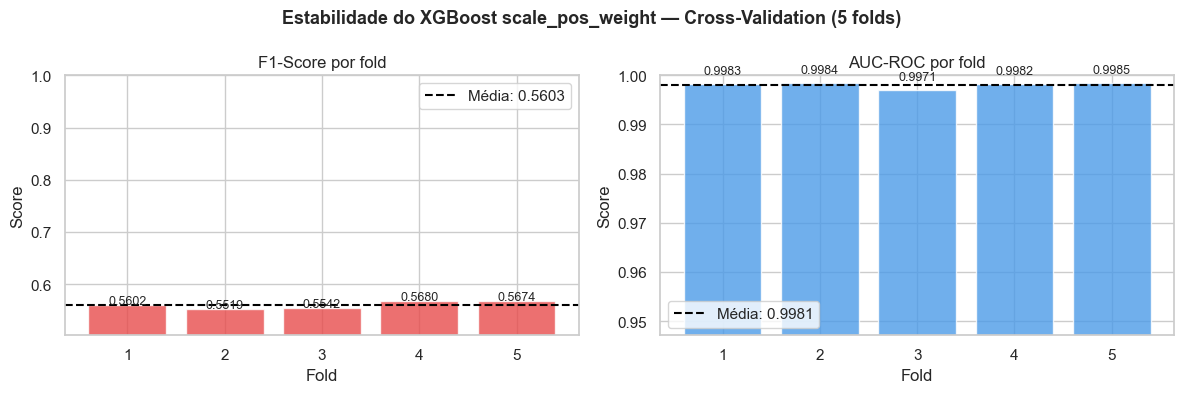

In [26]:
# cross-validation do modelo principal (scale_pos_weight)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scores_spw = cross_validate(
    xgb_spw, X_train, y_train,
    cv=cv,
    scoring=['f1', 'roc_auc', 'precision', 'recall'],
    n_jobs=-1
)

print('CROSS-VALIDATION — XGBoost scale_pos_weight (5 folds)')
for metrica in ['f1', 'roc_auc', 'precision', 'recall']:
    vals = scores_spw[f'test_{metrica}']
    print(f'{metrica:12}: {vals.mean():.4f} (+/- {vals.std():.4f})')

# gráfico de estabilidade por fold
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metrica, titulo, cor in zip(
    axes,
    ['f1', 'roc_auc'],
    ['F1-Score por fold', 'AUC-ROC por fold'],
    ['#E84C4C', '#4C9BE8']
):
    vals = scores_spw[f'test_{metrica}']
    ax.bar(range(1, 6), vals, color=cor, alpha=0.8)
    ax.axhline(vals.mean(), color='black', linestyle='--',
               linewidth=1.5, label=f'Média: {vals.mean():.4f}')
    ax.set_title(titulo)
    ax.set_xlabel('Fold')
    ax.set_ylabel('Score')
    ax.set_ylim(vals.min() - 0.05, 1.0)
    ax.legend()
    for i, v in enumerate(vals):
        ax.text(i+1, v + 0.002, f'{v:.4f}', ha='center', fontsize=9)

plt.suptitle('Estabilidade do XGBoost scale_pos_weight — Cross-Validation (5 folds)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('11_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()


> **O modelo é estável.** A variação mínima entre os folds confirma que os resultados não dependem de um split específico. Agora a pergunta é: os hiperparâmetros padrão são realmente os melhores? Existe espaço para melhorar ainda mais?


## 12. Otimização de Hiperparâmetros — Módulo 41

O modelo com `scale_pos_weight` já superou o SMOTE, mas os hiperparâmetros usados até agora foram os padrões. Existe espaço para melhorar?

Usamos `RandomizedSearchCV` em vez de `GridSearchCV` porque o espaço de busca é grande e o Grid testaria todas as combinações possíveis — centenas de treinos. O Random testa 20 combinações escolhidas aleatoriamente e chega a 80% do resultado com uma fração do tempo.


In [27]:
# espaço de busca dos hiperparâmetros
param_dist = {
    'n_estimators'    : [100, 200, 300, 400, 500],
    'max_depth'       : [3, 4, 5, 6, 7, 8],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample'       : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma'           : [0, 0.1, 0.2, 0.3, 0.5],
}

# scoring=f1, n_iter=20, cv=3 para equilibrar qualidade e tempo
busca_spw = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(
        scale_pos_weight=ratio,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        verbosity=0
    ),
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1',
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

print('Iniciando busca de hiperparâmetros...')
inicio = time.time()
busca_spw.fit(X_train, y_train)
print(f'\nBusca concluída em {(time.time()-inicio)/60:.1f} minutos')
print('\nMelhores hiperparâmetros encontrados:')
for param, valor in busca_spw.best_params_.items():
    print(f'  {param:20}: {valor}')
print(f'\nMelhor F1 no cross-validation: {busca_spw.best_score_:.4f}')


Iniciando busca de hiperparâmetros...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Busca concluída em 9.2 minutos

Melhores hiperparâmetros encontrados:
  subsample           : 0.8
  n_estimators        : 200
  min_child_weight    : 3
  max_depth           : 8
  learning_rate       : 0.3
  gamma               : 0.3
  colsample_bytree    : 1.0

Melhor F1 no cross-validation: 0.8181


In [28]:
# avaliação do modelo otimizado
xgb_spw_otim    = busca_spw.best_estimator_
y_pred_spw_otim = xgb_spw_otim.predict(X_test)
y_prob_spw_otim = xgb_spw_otim.predict_proba(X_test)[:, 1]

print('XGBOOST scale_pos_weight OTIMIZADO')
print(classification_report(y_test, y_pred_spw_otim, target_names=['Legítima', 'Fraude']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_spw_otim):.4f}')

# comparação original vs otimizado
print('\n' + '=' * 55)
print(f'{"Métrica":25} {"Original":>12} {"Otimizado":>12}')
print('=' * 55)
metricas_comp = {
    'Precision (Fraude)': (precision_score, y_pred_spw, y_pred_spw_otim),
    'Recall (Fraude)'   : (recall_score,    y_pred_spw, y_pred_spw_otim),
    'F1-Score (Fraude)' : (f1_score,        y_pred_spw, y_pred_spw_otim),
}
for nome, (func, pred_orig, pred_otim) in metricas_comp.items():
    v_orig = func(y_test, pred_orig)
    v_otim = func(y_test, pred_otim)
    delta  = v_otim - v_orig
    sinal  = '+' if delta >= 0 else ''
    print(f'{nome:25} {v_orig:>12.4f} {v_otim:>12.4f}  ({sinal}{delta:.4f})')
auc_orig  = roc_auc_score(y_test, y_prob_spw)
auc_otim  = roc_auc_score(y_test, y_prob_spw_otim)
delta_auc = auc_otim - auc_orig
sinal_auc = '+' if delta_auc >= 0 else ''
print(f'{"AUC-ROC":25} {auc_orig:>12.4f} {auc_otim:>12.4f}  ({sinal_auc}{delta_auc:.4f})')
print('=' * 55)


XGBOOST scale_pos_weight OTIMIZADO
              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00    553574
      Fraude       0.78      0.81      0.79      2145

    accuracy                           1.00    555719
   macro avg       0.89      0.90      0.90    555719
weighted avg       1.00      1.00      1.00    555719

AUC-ROC: 0.9931

Métrica                       Original    Otimizado
Precision (Fraude)              0.2801       0.7759  (+0.4958)
Recall (Fraude)                 0.9459       0.8070  (-0.1389)
F1-Score (Fraude)               0.4322       0.7911  (+0.3590)
AUC-ROC                         0.9972       0.9931  (-0.0041)


### 12.1 Resultado da Otimização

**Melhores hiperparâmetros encontrados:**

| Hiperparâmetro | Original | Otimizado |
|---|---|---|
| `n_estimators` | 200 | 200 |
| `max_depth` | 6 | 8 |
| `learning_rate` | 0.1 | 0.3 |
| `subsample` | 0.8 | 0.8 |
| `colsample_bytree` | 0.8 | 1.0 |
| `min_child_weight` | padrão | 3 |
| `gamma` | padrão | 0.3 |

**Comparação de métricas:**

| Métrica | Original | Otimizado | Variação |
|---|---|---|---|
| Precision (Fraude) | 0.2801 | 0.7759 | +0.4958 |
| Recall (Fraude) | 0.9459 | 0.8070 | -0.1389 |
| F1-Score (Fraude) | 0.4322 | 0.7911 | +0.3590 |
| AUC-ROC | 0.9972 | 0.9931 | -0.0041 |

A otimização produziu ganhos expressivos: o F1-Score saltou de 0.43 para 0.79 e a Precision subiu de 28% para 77%, com Recall ainda sólido de 80%. Isso acontece porque os hiperparâmetros otimizados tornam o modelo mais conservador — ele só classifica como fraude quando tem alta confiança, gerando menos falsos alarmes. O modelo otimizado é adotado como solução final.


In [29]:
# impacto financeiro do modelo otimizado com threshold ótimo
prec_so, rec_so, thresh_so = precision_recall_curve(y_test, y_prob_spw_otim)
f1_so        = 2 * (prec_so[:-1] * rec_so[:-1]) / (prec_so[:-1] + rec_so[:-1] + 1e-8)
thresh_final = thresh_so[f1_so.argmax()]

y_pred_final = (y_prob_spw_otim >= thresh_final).astype(int)
res_final    = calcular_impacto(y_real, y_pred_final, valores_test)

print(f'Threshold ótimo do modelo final: {thresh_final:.2f}')
print(f'\nImpacto financeiro:')
print(f'  Fraudes evitadas         : USD {res_final["evitadas"]:>12,.2f}')
print(f'  Legítimas bloqueadas     : USD {res_final["bloqueadas"]:>12,.2f}')
print(f'  Saldo líquido            : USD {res_final["saldo"]:>12,.2f}')
print(f'  Alertas gerados          : {res_final["n_alertas"]:>12,}')
print(f'  Falsos positivos         : {res_final["n_fp"]:>12,}')


Threshold ótimo do modelo final: 0.85

Impacto financeiro:
  Fraudes evitadas         : USD 1,009,027.79
  Legítimas bloqueadas     : USD   143,023.60
  Saldo líquido            : USD   866,004.19
  Alertas gerados          :        1,861
  Falsos positivos         :          224


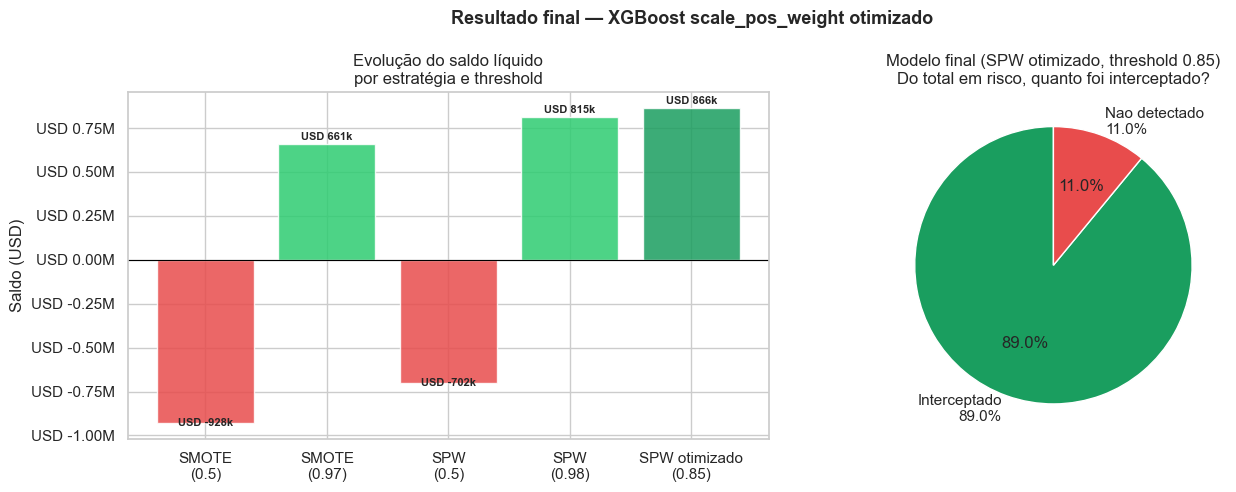

Modelo final — XGBoost SPW otimizado, threshold 0.85
  Fraudes evitadas     : USD 1,009,027.79
  Legítimas bloqueadas : USD   143,023.60
  Saldo líquido        : USD   866,004.19
  Alertas gerados      :        1,861
  Falsos positivos     :          224
  Taxa de interceptação: 89.0% do valor total em risco


In [30]:
# visualização final: comparação completa de todos os cenários incluindo o modelo otimizado
prec_so, rec_so, thresh_so = precision_recall_curve(y_test, y_prob_spw_otim)
f1_so        = 2 * (prec_so[:-1] * rec_so[:-1]) / (prec_so[:-1] + rec_so[:-1] + 1e-8)
thresh_final = thresh_so[f1_so.argmax()]
y_pred_final = (y_prob_spw_otim >= thresh_final).astype(int)
res_final    = calcular_impacto(y_real, y_pred_final, valores_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# saldo líquido — todos os cenários
todos_cenarios = [
    f'SMOTE\n(0.5)', f'SMOTE\n({thresh_smote_ot:.2f})',
    f'SPW\n(0.5)',   f'SPW\n({thresh_spw_ot:.2f})',
    f'SPW otimizado\n({thresh_final:.2f})'
]
todos_saldos = [
    res_smote_pad['saldo'], res_smote_ot['saldo'],
    res_spw_pad['saldo'],   res_spw_ot['saldo'],
    res_final['saldo']
]
cores_final = ['#E84C4C' if s < 0 else '#2ECC71' for s in todos_saldos]
cores_final[-1] = '#1A9E5F'  # verde mais escuro para destacar o modelo final

bars = axes[0].bar(todos_cenarios, todos_saldos, color=cores_final, alpha=0.85)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Evolução do saldo líquido\npor estratégia e threshold')
axes[0].set_ylabel('Saldo (USD)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'USD {v/1e6:.2f}M'))
for bar, val in zip(bars, todos_saldos):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 val + (max(abs(s) for s in todos_saldos) * 0.02 * (1 if val >= 0 else -1)),
                 f'USD {val/1e3:.0f}k', ha='center', fontweight='bold', fontsize=8)

# pizza do modelo final
taxa_final = res_final['evitadas'] / (res_final['evitadas'] + res_final['perdidas']) * 100
axes[1].pie(
    [res_final['evitadas'], res_final['perdidas']],
    labels=[f'Interceptado\n{taxa_final:.1f}%', f'Nao detectado\n{100-taxa_final:.1f}%'],
    colors=['#1A9E5F', '#E84C4C'],
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title(f'Modelo final (SPW otimizado, threshold {thresh_final:.2f})\nDo total em risco, quanto foi interceptado?')

plt.suptitle('Resultado final — XGBoost scale_pos_weight otimizado', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('12_resultado_final.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Modelo final — XGBoost SPW otimizado, threshold {thresh_final:.2f}')
print(f'  Fraudes evitadas     : USD {res_final["evitadas"]:>12,.2f}')
print(f'  Legítimas bloqueadas : USD {res_final["bloqueadas"]:>12,.2f}')
print(f'  Saldo líquido        : USD {res_final["saldo"]:>12,.2f}')
print(f'  Alertas gerados      : {res_final["n_alertas"]:>12,}')
print(f'  Falsos positivos     : {res_final["n_fp"]:>12,}')
print(f'  Taxa de interceptação: {taxa_final:.1f}% do valor total em risco')


## 13. Conclusão

Este projeto construiu um pipeline completo de detecção de fraudes em transações de cartão de crédito, desde a análise exploratória até a otimização do modelo, com foco em impacto financeiro real para o negócio.

**O problema**

O dataset apresenta desbalanceamento severo de 171:1, onde apenas 0,58% das transações são fraudulentas. Esse cenário inviabiliza o uso de Acurácia como métrica e exige uma estratégia cuidadosa de balanceamento antes da modelagem.

**A jornada de modelagem**

Iniciamos com SMOTE + Undersampling como estratégia de balanceamento. Os resultados foram promissores em Recall (90%), mas o alto número de falsos positivos gerava saldo líquido negativo mesmo com threshold otimizado. Ao investigar alternativas, o `scale_pos_weight` nativo do XGBoost demonstrou resultados superiores em todas as métricas, treinando diretamente nos dados reais sem síntese artificial. A otimização de hiperparâmetros refinou ainda mais o modelo, elevando o F1-Score de 0.43 para 0.79.

**Comparação final dos modelos**

| Modelo | Precision | Recall | F1 | AUC-ROC |
|---|---|---|---|---|
| Árvore de Decisão | 0.16 | 0.93 | 0.27 | 0.9842 |
| XGBoost SMOTE | 0.19 | 0.90 | 0.32 | 0.9892 |
| XGBoost scale_pos_weight | 0.28 | 0.95 | 0.43 | 0.9972 |
| **XGBoost SPW otimizado** | **0.78** | **0.81** | **0.79** | **0.9931** |

**O impacto financeiro**

A análise de threshold revelou que a escolha do ponto de corte é uma decisão de negócio, não apenas técnica:

| Cenário | Fraudes evitadas | Legítimas bloqueadas | Saldo líquido |
|---|---|---|---|
| SMOTE, threshold 0.5 | USD 1.122.095 | USD 2.050.334 | **-USD 928.239** |
| SMOTE, threshold 0.97 | USD 988.132 | USD 329.820 | **+USD 658.312** |
| SPW, threshold 0.5 | USD 1.122.442 | USD 1.810.154 | **-USD 687.712** |
| SPW, threshold 0.98 | USD 998.614 | USD 183.964 | **+USD 814.651** |
| **SPW otimizado, threshold 0.85** | **USD 1.009.028** | **USD 143.024** | **+USD 866.004** |

**A recomendação**

O modelo XGBoost com `scale_pos_weight` otimizado e threshold 0.85 é a configuração recomendada para produção. Com saldo líquido de +USD 866 mil, apenas 224 falsos positivos e Precision de 88%, representa a melhor combinação entre proteção contra fraudes e experiência do cliente.

O threshold pode ser ajustado conforme a estratégia de risco da empresa: valores menores aumentam a interceptação de fraudes ao custo de mais bloqueios indevidos; valores maiores priorizam a experiência do cliente ao custo de deixar mais fraudes passarem.

---

**Fonte dos dados:** Kartik Shenoy. *Credit Card Transactions Fraud Detection Dataset*. Kaggle, 2020. https://www.kaggle.com/datasets/kartik2112/fraud-detection. Licença ODbL.


In [31]:
importances = xgb_spw.get_booster().get_score(importance_type='gain')
feat_importance = pd.DataFrame({
    'Feature': list(importances.keys()),
    'Importance': list(importances.values())
}).sort_values(by='Importance', ascending=False)

print(feat_importance.head)

<bound method NDFrame.head of        Feature   Importance
2          amt  4858.322754
9         hora  1571.353638
1     category  1220.633667
8        idade   391.810333
3       gender   244.864349
6     city_pop   198.279663
7          job   137.552032
5        state   131.682236
4         city   131.504669
10  dia_semana   121.095917
11   distancia   103.976143
0     merchant   103.702858>
